In [13]:
import pandas as pd
df = pd.read_csv('../datasets/sentiment.csv') # columns: 'text','label'
print(df['label'].value_counts())


label
1    5
0    5
Name: count, dtype: int64


In [14]:
import re
stop = set(['the','is','in','and','to','a','of'])
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]','', text) 
    tokens = text.split()
    return [t for t in tokens if t not in stop]
# Example:
print(preprocess("This is an example!"))

['this', 'an', 'example']


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
df = pd.read_csv('../datasets/sentiment.csv')
X = df['text']; y = df['label']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)
vec = TfidfVectorizer()
Xtr = vec.fit_transform(X_train)
Xte = vec.transform(X_test)
clf = LogisticRegression(max_iter=1000).fit(Xtr,y_train)
pred = clf.predict(Xte)
print('Accuracy:', accuracy_score(y_test,pred))

Accuracy: 0.0


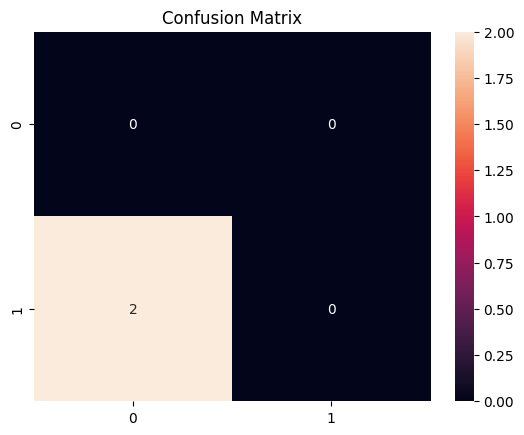

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.savefig('../datasets/sentiment_cm.png')

In [18]:
from collections import Counter
import pandas as pd
df = pd.read_csv('../datasets/sentiment.csv')
pos = ' '.join(df[df['label']==1]['text']).lower().split()
neg = ' '.join(df[df['label']==0]['text']).lower().split()
print('Top positive words:', Counter(pos).most_common(10))
print('Top negative words:', Counter(neg).most_common(10))

Top positive words: [('the', 2), ('is', 2), ('very', 2), ('i', 1), ('love', 1), ('this', 1), ('phone', 1), ('it', 1), ('works', 1), ('perfectly', 1)]
Top negative words: [('the', 3), ('this', 2), ('is', 1), ('worst', 1), ('service', 1), ('ever', 1), ('i', 1), ('hate', 1), ('product', 1), ('completely', 1)]
